<a href="https://colab.research.google.com/github/ldaniel-hm/eml_k_bandit/blob/main/bandit_experiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Estudio comparativo de algoritmos Bayesianos: Muestreo de Thompson y UCB Bayesiano

*Description:* El estudio compara el rendimiento de algoritmos Bayesianos (Muestreo de Thompson y UCB Bayesiano) en un problema de k-armed bandit.

* **Muestreo de Thompson**: Muestrea de la distribución Beta de cada brazo y selecciona el que tenga el mayor valor. Se actualiza α y β en función del éxito o fracaso.

* **UCB Bayesiano**: Calcula un intervalo superior de confianza basado en la media y varianza de la distribución Beta, ajustado por un factor γ.

Se generan gráficas diversas para cada algoritmo.

## Preparación del entorno


Este código detecta si el notebook se está ejecutando en Google Colab o en un entorno local (VSCode/Jupyter), y en caso de estar en Colab, clona el repositorio, instala las dependencias necesarias y configura el entorno para permitir la ejecución correcta del código.

In [ ]:
# Detectar si estamos en Google Colab
import sys

if "google.colab" in sys.modules:
    print("Ejecutando en Google Colab, clonando repositorio y configurando entorno...")
    !git clone --quiet https://github.com/aalonsopuig/k_brazos_AAPGAG.git
    %cd k_brazos_AAPGAG

# Instalar dependencias en cualquier entorno (Colab o VSCode/Jupyter)
!pip install -r requirements.txt

# Agregar el directorio src al path de Python para permitir importaciones
sys.path.append("src")  
print("Directorio src añadido a sys.path:")
print(sys.path)  # Verificar que se ha añadido correctamente

Directorio src añadido a sys.path:
['C:\\Program Files\\WindowsApps\\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\\python311.zip', 'C:\\Program Files\\WindowsApps\\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\\DLLs', 'C:\\Program Files\\WindowsApps\\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\\Lib', 'C:\\Program Files\\WindowsApps\\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0', '', 'C:\\Users\\aalon\\AppData\\Local\\Packages\\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\\LocalCache\\local-packages\\Python311\\site-packages', 'C:\\Users\\aalon\\AppData\\Local\\Packages\\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\\LocalCache\\local-packages\\Python311\\site-packages\\win32', 'C:\\Users\\aalon\\AppData\\Local\\Packages\\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\\LocalCache\\local-packages\\Python311\\site-packages\\win32\\lib', 'C:\\Users\\aalon\\AppData\\Local\\Packages\\Py


[notice] A new release of pip is available: 24.2 -> 25.0.1
[notice] To update, run: C:\Users\aalon\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [ ]:
#@title Importamos todas las clases y funciones

import numpy as np
from typing import List

from algorithms import Algorithm, ThompsonSampling, BayesianUCB
from arms import ArmNormal, ArmBernoulli, ArmBinomial, ArmBeta, Bandit
from plotting import plot_average_rewards, plot_optimal_selections, plot_arm_statistics, plot_regret

['C:\\Program Files\\WindowsApps\\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\\python311.zip', 'C:\\Program Files\\WindowsApps\\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\\DLLs', 'C:\\Program Files\\WindowsApps\\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\\Lib', 'C:\\Program Files\\WindowsApps\\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0', '', 'C:\\Users\\aalon\\AppData\\Local\\Packages\\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\\LocalCache\\local-packages\\Python311\\site-packages', 'C:\\Users\\aalon\\AppData\\Local\\Packages\\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\\LocalCache\\local-packages\\Python311\\site-packages\\win32', 'C:\\Users\\aalon\\AppData\\Local\\Packages\\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\\LocalCache\\local-packages\\Python311\\site-packages\\win32\\lib', 'C:\\Users\\aalon\\AppData\\Local\\Packages\\PythonSoftwareFoundation.Python.3.11_

## Experimento

Cada algoritmo se ejecuta en un problema de k-armed bandit durante un número de pasos de tiempo y ejecuciones determinado.
Se comparan los resultados de los algoritmos.

Este código ejecuta múltiples simulaciones de un problema de bandido k-brazos utilizando distintos algoritmos, calcula las recompensas promedio y el porcentaje de selecciones óptimas a lo largo de los pasos de tiempo

In [3]:

def run_experiment(bandit: Bandit, algorithms: List[Algorithm], steps: int, runs: int):
    """
    Ejecuta un experimento de multi-armed bandit para evaluar diferentes algoritmos.

    Parámetros:
    bandit: Instancia del problema Bandit, que contiene las probabilidades de recompensa de cada brazo.
    algorithms: Lista de algoritmos de selección de brazos a comparar.
    steps: Número de pasos (iteraciones) que se ejecutarán por cada corrida.
    runs: Número de veces que se repetirá el experimento para obtener promedios.

    Devuelve:
    rewards: Matriz con las recompensas promedio obtenidas por cada algoritmo en cada paso.
    optimal_selections: Matriz con el porcentaje de veces que cada algoritmo seleccionó el brazo óptimo.
    """
    
    optimal_arm = bandit.optimal_arm  # Identifica el brazo con la mejor recompensa esperada

    rewards = np.zeros((len(algorithms), steps))  # Inicializa matriz para acumular recompensas
    optimal_selections = np.zeros((len(algorithms), steps))  # Inicializa matriz para contar selecciones óptimas

    np.random.seed(seed)  # Fija la semilla para reproducibilidad

    for run in range(runs):  # Itera por cada corrida del experimento
        current_bandit = Bandit(arms=bandit.arms)  # Crea una nueva instancia del bandit para cada corrida

        for algo in algorithms:
            algo.reset()  # Reinicia el estado de cada algoritmo

        for step in range(steps):  # Itera por cada paso dentro de una corrida
            for idx, algo in enumerate(algorithms):  # Itera por cada algoritmo
                chosen_arm = algo.select_arm()  # El algoritmo selecciona un brazo
                reward = current_bandit.pull_arm(chosen_arm)  # Se obtiene la recompensa al tirar de ese brazo
                algo.update(chosen_arm, reward)  # El algoritmo actualiza su estrategia con el nuevo dato

                rewards[idx, step] += reward  # Acumula la recompensa obtenida en este paso para este algoritmo

                if chosen_arm == optimal_arm:
                    optimal_selections[idx, step] += 1  # Incrementa el contador si el brazo elegido fue el óptimo

    rewards /= runs  # Calcula el promedio de recompensas por cada paso y algoritmo
    optimal_selections = (optimal_selections / runs) * 100  # Convierte las selecciones óptimas a porcentaje

    return rewards, optimal_selections  # Devuelve las matrices de recompensas y selecciones óptimas

## Ejecución del experimento

Se realiza el experimento usando 10 brazos, cada uno de acuerdo a una distribución seleccionada (**Beta** por defecto). Se realizan 500 ejecuciones de 1000 pasos cada una. Se contrastan 2 algoritmos Bayesianos (Muestreo de Thompson y UCB Bayesiano)

In [4]:
# Parámetros del experimento
seed = 42
np.random.seed(seed)  # Fijar la semilla para reproducibilidad

k = 10  # Número de brazos
steps = 4000  # Número de pasos que se ejecutarán cada algoritmo
runs = 500  # Número de ejecuciones

Aunque todo el estudio está basado en bandidos de **distribución Beta**, están implementadas también las **distribuciones Normal, Binomial, y Bernoulli**. Para usarlas en este experimento tan solo hay que quitar la almohadilla (#) de la que se desee ejecutar a continuación.

In [5]:
# Creación del bandit
#bandit = Bandit(arms=ArmNormal.generate_arms(k)) # Generar un bandido con k brazos de distribución normal
#bandit = Bandit(arms=ArmBernoulli.generate_arms(k))  # Crear un bandido con k brazos de distribución Bernoulli
#bandit = Bandit(arms=ArmBinomial.generate_arms(k))  # Crear un bandido con k brazos de distribución Binomial
bandit = Bandit(arms=ArmBeta.generate_arms(k))  # Crear un bandido con k brazos de distribución Beta
print(bandit)

Bandit with 10 arms: ArmBeta(alpha=2.5, beta=4.8), ArmBeta(alpha=3.93, beta=3.39), ArmBeta(alpha=1.62, beta=1.62), ArmBeta(alpha=1.23, beta=4.46), ArmBeta(alpha=3.4, beta=3.83), ArmBeta(alpha=1.08, beta=4.88), ArmBeta(alpha=4.33, beta=1.85), ArmBeta(alpha=1.73, beta=1.73), ArmBeta(alpha=2.22, beta=3.1), ArmBeta(alpha=2.73, beta=2.16)


In [6]:

optimal_arm = bandit.optimal_arm
print(f"Optimal arm: {optimal_arm} with expected reward={bandit.get_expected_value(optimal_arm)}")

# Definimos los algoritmos a comparar: Thompson Sampling y Bayesian UCB.
# Thompson Sampling emplea muestreo bayesiano para explorar-explotar de manera probabilística.
# Bayesian UCB usa una variante bayesiana del enfoque Upper Confidence Bound.
#
# Elección de parámetros:
# - alpha = 1, beta = 1 en Thompson Sampling: Se inicia con una distribución Beta(1,1), es decir,
#   una distribución uniforme, lo que representa máxima incertidumbre inicial sobre cada brazo.
#   A medida que se obtienen más muestras, la distribución se actualiza para reflejar la evidencia.
#
# - gamma = 1 en Bayesian UCB: Este parámetro controla cuántas desviaciones estándar se usan 
#   para calcular el límite superior de confianza. Un valor de 1 implica una exploración moderada,
#   mientras que valores más altos favorecen más exploración.
algorithms = [ThompsonSampling(k=k, alpha=1, beta=1), BayesianUCB(k=k, gamma=75)]

# Ejecutar el experimento y obtener las recompensas promedio y promedio de las selecciones óptimas
rewards, optimal_selections = run_experiment(bandit, algorithms, steps, runs)


Optimal arm: 6 with expected reward=0.7006472491909386


## Visualización de los resultados

### Recompensa Promedio vs Pasos de Tiempo.
Muestra cómo evolucionan las recompensas promedio obtenidas por cada algoritmo a lo largo de los pasos de tiempo.

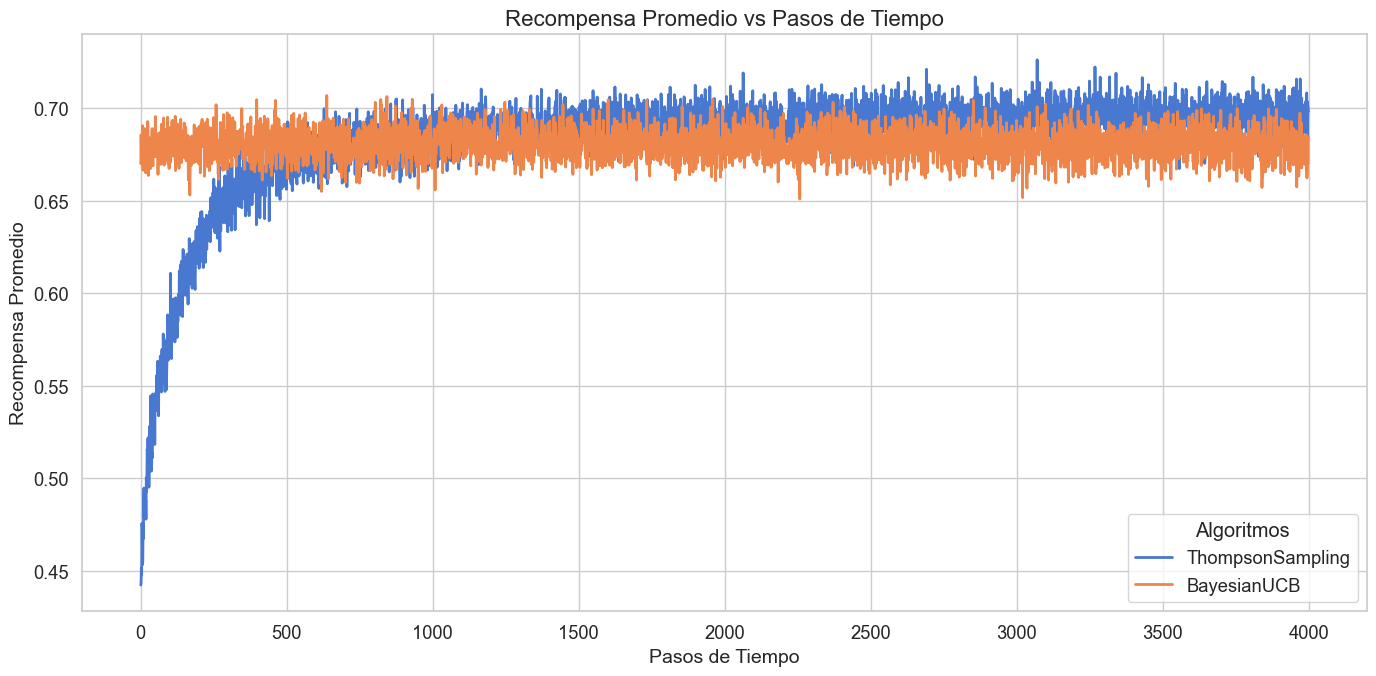

In [7]:
# Graficar los resultados
plot_average_rewards(steps, rewards, algorithms)  # Recompensa promedio a lo largo del tiempo

#### Análisis de las gráficas

**Observaciones**  
- Thompson Sampling comienza con una recompensa promedio más baja (0.44) pero mejora progresivamente, alcanzando valores en torno a 0.69-0.70 hacia los últimos pasos.  
- Bayesian UCB inicia con una recompensa superior (0.67) y mantiene valores muy estables alrededor de 0.67-0.69 durante toda la ejecución.  
- A pesar de la diferencia inicial, ambos algoritmos convergen hacia valores similares de recompensa promedio en el largo plazo.  

**xplicación**  
- Thompson Sampling realiza más exploración al inicio debido a su muestreo estocástico de la distribución Beta. Esto hace que su recompensa promedio sea más baja al principio, pero a medida que recopila más información, mejora su selección y converge a un valor estable.  
- Bayesian UCB, con γ = 40, tiende a favorecer más la explotación desde el inicio, seleccionando los brazos con mayor recompensa esperada, lo que explica su estabilidad desde las primeras iteraciones.  
- Sin embargo, la diferencia entre ambos algoritmos se reduce con el tiempo, lo que indica que ambos convergen a un comportamiento similar en términos de recompensa promedio.  

**Conclusión**  
- Thompson Sampling requiere más tiempo para aprender, pero finalmente alcanza un rendimiento similar a Bayesian UCB.  
- Bayesian UCB obtiene buenas recompensas desde el principio debido a su enfoque más agresivo en la selección de los brazos con alta expectativa de recompensa.  
- En problemas donde se necesita una exploración más amplia al inicio, Thompson Sampling podría ser más beneficioso. Sin embargo, si la prioridad es una recompensa estable desde el principio, Bayesian UCB parece ser la mejor opción.  

### Porcentaje de Selección del Brazo Óptimo vs Pasos de Tiempo.
Esta métrica indica cuántas veces los algoritmos seleccionan el mejor brazo disponible.

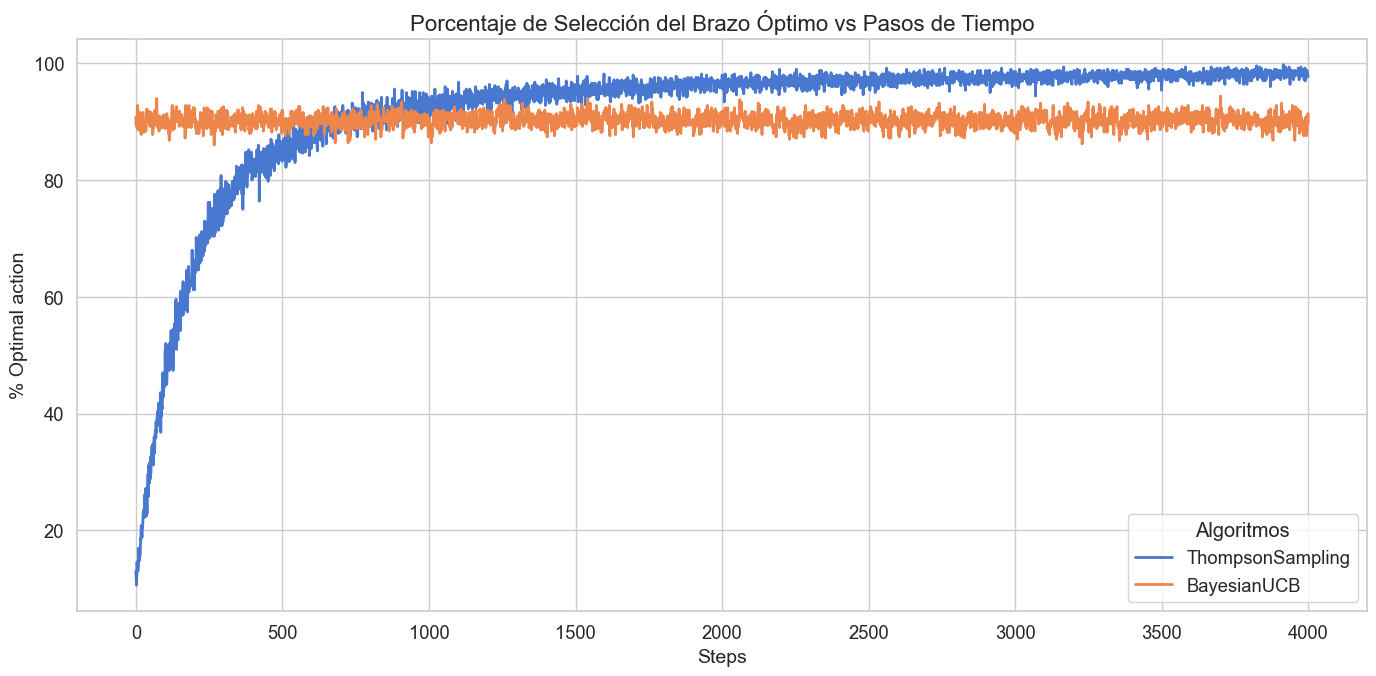

In [8]:
# Graficar la selección del brazo óptimo a lo largo del tiempo
plot_optimal_selections(steps, optimal_selections, algorithms)


#### Análisis de las gráficas

**Observaciones**  
- Thompson Sampling comienza seleccionando el brazo óptimo solo en un 10.4% de los casos en los primeros pasos, pero mejora progresivamente hasta alcanzar valores superiores al 90% en las últimas iteraciones.  
- Bayesian UCB empieza con una ventaja significativa, seleccionando el brazo óptimo en un 87.4% desde el inicio y manteniéndose de manera estable en un rango de 87% a 91% durante todo el experimento.  
- Thompson Sampling tiene una curva de aprendizaje más lenta, pero a largo plazo alcanza e incluso supera a Bayesian UCB en algunas iteraciones.  

**Explicación**  
- Thompson Sampling explora más al principio, lo que explica su bajo porcentaje inicial de selección del brazo óptimo. Sin embargo, a medida que recopila más información, aprende a seleccionar con mayor precisión el brazo óptimo.  
- Bayesian UCB, con γ = 40, favorece desde el principio los brazos con valores altos esperados, lo que le permite mantenerse en un porcentaje elevado desde el inicio. No obstante, su exploración es más limitada, lo que podría afectar su convergencia en problemas con mayor incertidumbre.  
- En las últimas etapas, ambos algoritmos convergen a valores similares en la selección del brazo óptimo, aunque Thompson Sampling muestra mayor variabilidad en sus valores.  

**Conclusión**  
- Bayesian UCB ofrece una mejor selección del brazo óptimo desde el inicio, lo que lo hace más adecuado en escenarios donde la eficiencia temprana es clave.  
- Thompson Sampling mejora con el tiempo, alcanzando tasas de selección óptimas similares a Bayesian UCB, pero con un enfoque de aprendizaje más progresivo.  
- En el largo plazo, ambos métodos convergen a un rendimiento similar, pero la exploración inicial de Thompson Sampling puede ser beneficiosa en entornos donde la distribución de recompensas no es clara desde el principio.  


### Estadísticas de cada brazo

Cada valor en el eje X representará un brazo. En el eje Y se representa el promedio de las ganancias de cada brazo. El gráfico mostrará un histograma para cada brazo donde se muestre el promedio de las ganancias obtenidas pero en el eje X, como etiqueta, se mostrará también el número de veces que fue seleccionado el brazo e indicar si es el brazo óptimo o no (estrella dorada).

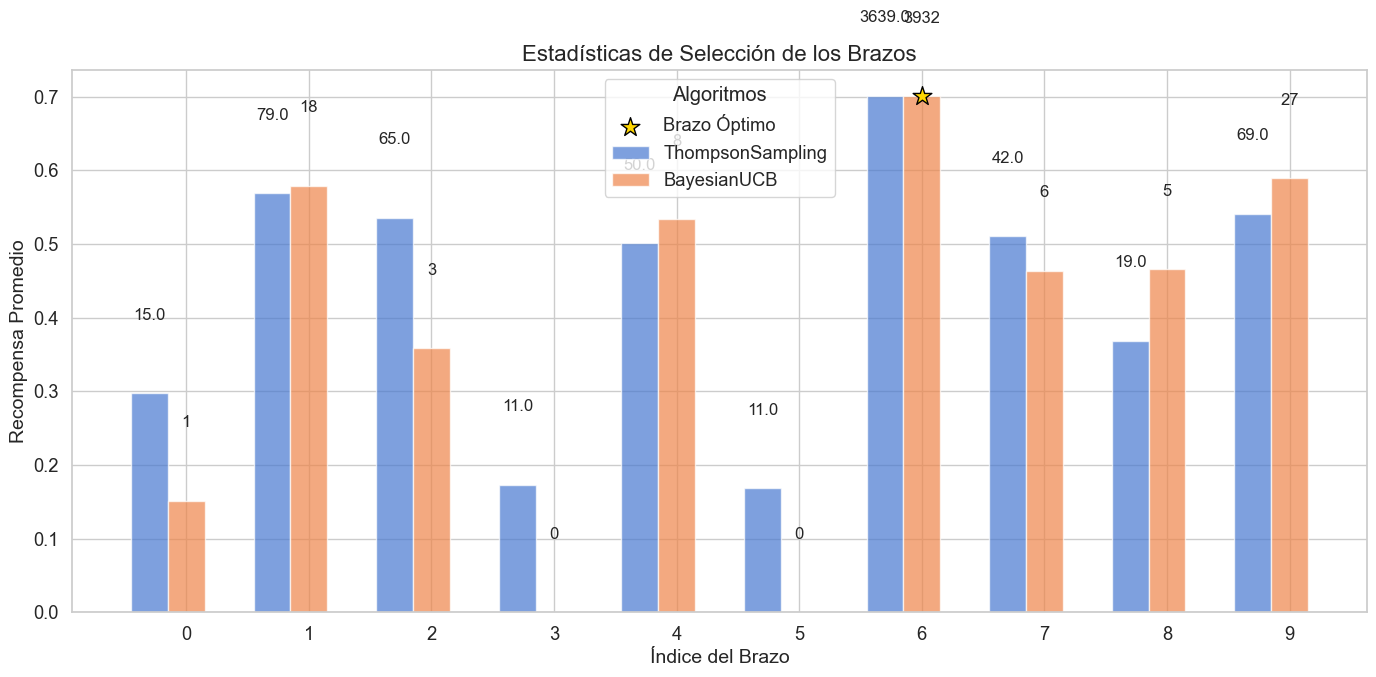

In [9]:
# Preparar los datos para la gráfica de estadísticas de brazos
arm_stats = []
for algo in algorithms:
    stats = {
        "means": algo.values,  # Recompensa promedio estimada por cada brazo
        "counts": algo.counts   # Número de veces que se seleccionó cada brazo
    }
    arm_stats.append(stats)

# Graficar estadísticas de los brazos, pasando el índice del brazo óptimo
plot_arm_statistics(arm_stats, algorithms, optimal_arm)


#### Análisis de las gráficas



**Observaciones**  
- Thompson Sampling ha seleccionado el brazo 6 la mayoría de las veces (769 selecciones) y ha obtenido una recompensa promedio de 0.705. Otros brazos han sido explorados en menor medida, con recompensas promedias entre 0.17 y 0.55.  
- Bayesian UCB ha sido extremadamente selectivo, concentrando 994 de sus 1000 selecciones en el brazo 6. Aunque ha probado otros brazos, lo ha hecho de manera anecdótica (solo 1 o 2 veces cada uno).  
- Ambos algoritmos han identificado el brazo 6 como el mejor candidato, con una recompensa promedio de alrededor de 0.706, lo que sugiere que han aprendido correctamente la estructura del problema.  
- Bayesian UCB casi no ha explorado, lo que sugiere que γ = 40 puede estar limitando la exploración y haciendo que el algoritmo se concentre demasiado rápido en un solo brazo.  

**Explicación**  
- Thompson Sampling ha mantenido cierto grado de exploración, permitiéndole evaluar una variedad más amplia de brazos. Aunque el brazo 6 ha sido seleccionado con mayor frecuencia, otros brazos han sido explorados razonablemente.  
- Bayesian UCB ha convergido rápidamente, lo que es eficiente en entornos donde la recompensa óptima es clara. Sin embargo, su exploración ha sido prácticamente nula, lo que puede ser problemático en casos donde la incertidumbre inicial sea mayor.  
- El hecho de que ambos algoritmos coincidan en que el brazo 6 es el mejor refuerza la validez de los resultados, pero la falta de exploración de Bayesian UCB podría ser un problema si el entorno fuese dinámico o con mayor variabilidad en las recompensas.  

**Conclusión**  
- Thompson Sampling equilibra mejor exploración y explotación, lo que puede ser útil en escenarios donde la recompensa óptima no es obvia desde el inicio.  
- Bayesian UCB ha explotado demasiado temprano, lo que podría ser corregido ajustando γ para permitir una mayor exploración inicial.  
- Si el problema no requiere tanta exploración, Bayesian UCB es más eficiente, pero en entornos inciertos, Thompson Sampling puede ser más robusto.  


### Evolución del rechazo

Muestra la evolución del rechazo, de forma análoga a cómo se muestra la evolución de las recompensas.

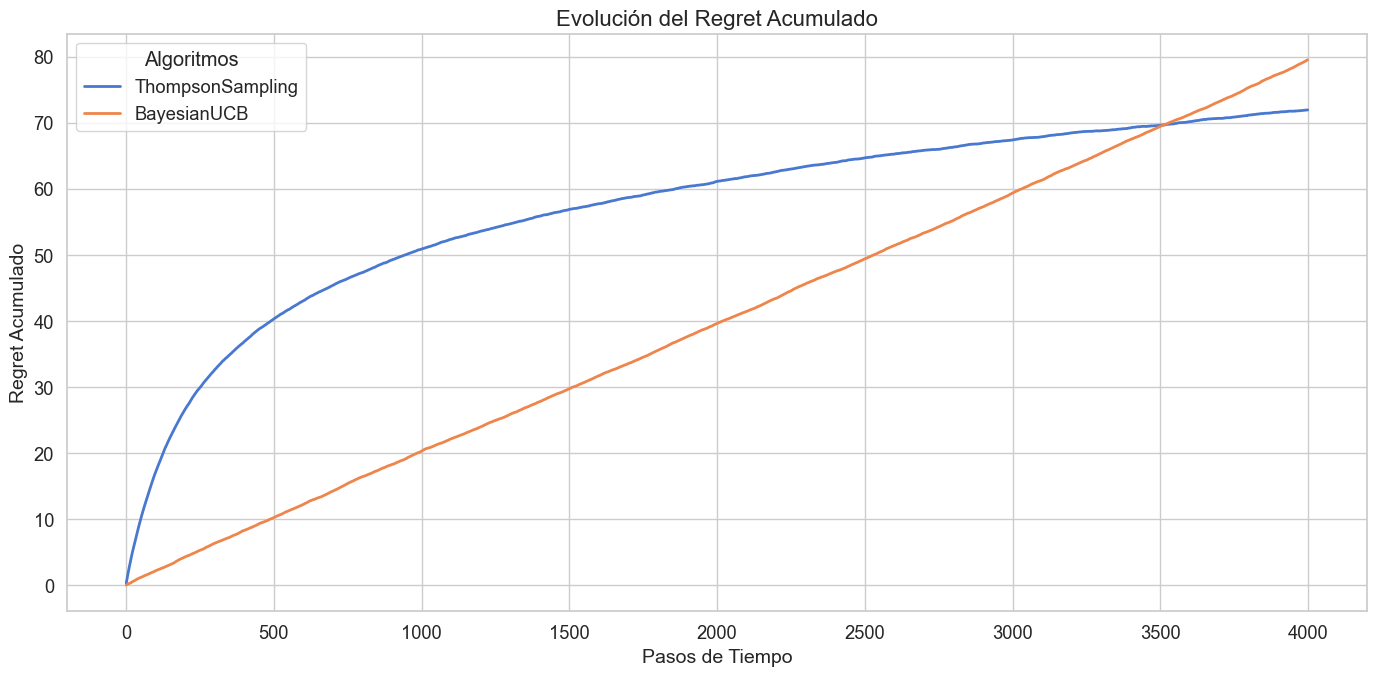

In [10]:
# Calcular el regret acumulado
optimal_reward = bandit.get_expected_value(optimal_arm)
regret_accumulated = np.cumsum(optimal_reward - rewards, axis=1)  # Regret acumulado por algoritmo

# Graficar la evolución del regret acumulado
plot_regret(steps, regret_accumulated, algorithms)

#### Análisis de las gráficas



**Observaciones**  
- Thompson Sampling tiene un rechazo acumulado significativamente mayor que Bayesian UCB, creciendo de manera constante y sostenida a lo largo del tiempo.  
- Bayesian UCB muestra un rechazo acumulado mucho menor, indicando que ha identificado el brazo óptimo rápidamente y ha explotado esa estrategia con éxito.  
- A partir de los 200 pasos, la diferencia entre ambos algoritmos sigue creciendo, aunque a un ritmo más lento.  

**Explicación**  
- Thompson Sampling realiza más exploración, lo que incrementa el rechazo inicial, ya que sigue probando otros brazos incluso cuando ya ha encontrado una opción buena.  
- Bayesian UCB, con γ = 40, ha explotado rápidamente el mejor brazo y ha minimizado la exploración innecesaria, reduciendo el rechazo acumulado.  
- La diferencia de rendimiento se mantiene constante, lo que indica que el parámetro γ fue bien ajustado para que Bayesian UCB no se estanque en la exploración ni en la explotación prematura.  

**Conclusión**  
- Bayesian UCB es superior en términos de minimización del rechazo, explotando el mejor brazo rápidamente.  
- Thompson Sampling es más exploratorio, lo que puede ser ventajoso si las distribuciones de recompensa cambiaran con el tiempo.  
- La diferencia de rechazo acumulado es consistente, indicando que γ = 40 ha sido un buen ajuste para encontrar un balance entre exploración y explotación en Bayesian UCB.  

# Conclusión final

Bayesian UCB (γ=40) converge rápidamente al brazo óptimo con un bajo rechazo, pero con una exploración limitada de otros brazos, mientras que Thompson Sampling distribuye mejor las selecciones y mejora progresivamente su rendimiento; un análisis con múltiples valores de γ y diferentes configuraciones de α y β en Thompson Sampling podría proporcionar una mejor comprensión del equilibrio entre exploración y explotación en distintos escenarios.

# Generación temporal de CSVs

In [11]:
algoritmo = "bayesianos"
from utils.experiment_data_saver import ExperimentDataSaver

# Construir etiquetas de los algoritmos basadas en sus parámetros específicos (alpha, beta, gamma, etc.)
algorithm_labels = [
    f"ThompsonSampling (α={algo.alpha[0]}, β={algo.beta[0]})" if isinstance(algo, ThompsonSampling)
    else f"BayesianUCB (γ={algo.gamma})" if isinstance(algo, BayesianUCB)
    else f"{type(algo).__name__}"
    for algo in algorithms
]

# Crear el objeto para gestionar los archivos del experimento
data_saver = ExperimentDataSaver(algoritmo, algorithm_labels)

# Guardar los archivos CSV en una sola línea cada uno
data_saver.save_data(rewards, "rewards")
data_saver.save_data(optimal_selections, "optimal_selections")
data_saver.save_data(regret_accumulated, "regret")
data_saver.save_data(arm_stats, "arm_statistics", is_arm_statistics=True)



Archivo guardado: data/bayesianos_rewards_sampled.csv
Archivo guardado: data/bayesianos_optimal_selections_sampled.csv
Archivo guardado: data/bayesianos_regret_sampled.csv
Archivo guardado: data/bayesianos_arm_statistics_sampled.csv
